In [1]:
# ============================================================
# CELL 1 — Environment Setup + Architecture Prep for Fine-Tuning
# ============================================================
# This notebook takes the generic LOSO models from Notebook 07
# and fine-tunes them on subject-specific baseline data.
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
from google.colab import drive

# --- Mount Drive -------------------------------------------
drive.mount('/content/drive', force_remount=False)

# --- Base Paths (Inherited from Notebook 07) ---------------
BASE            = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs'
MASKED_DIR      = os.path.join(BASE, 'MASKED_LSTM_AE')
FORECAST_DIR    = os.path.join(BASE, 'SEQ2SEQ_FORECASTER')

# Paths for the generic models we are about to fine-tune
LOSO_MODELS_DIR = os.path.join(FORECAST_DIR, 'models')
PREV_CHECKPOINT_DIR = os.path.join(BASE, 'LSTM_AE', 'checkpoints')

# New home for the personalized (fine-tuned) models
PERS_DIR         = os.path.join(BASE, 'PERSONALIZED_FORECASTER')
PERS_MODELS_DIR  = os.path.join(PERS_DIR, 'models')
PERS_RESULTS_DIR = os.path.join(PERS_DIR, 'results')

for d in [PERS_MODELS_DIR, PERS_RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f'  Ready: {d}')

# --- Locked Constants (Must match Notebook 07 exactly) ------
N_FEATURES      = 10    # Width of each feature vector
T               = 5     # AE internal sequence window
HIDDEN_SIZE     = 64    # AE bottleneck / embedding dimension
LOOKBACK_STEPS  = 15    # 15 minutes of encoded history
FORECAST_STEPS  = 10    # Predicting 10 minutes ahead

print(f'\n--- Constants locked ---')
print(f'  AE window    : T={T} steps')
print(f'  Lookback     : {LOOKBACK_STEPS} min')
print(f'  Forecast     : {FORECAST_STEPS} min ahead')

# --- Device ------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n  Device: {device}')

# --- Rebuild Architectures ---------------------------------

class MaskedLSTMAutoEncoder(nn.Module):
    def __init__(self, n_features=10, hidden_size=64, n_layers=1):
        super(MaskedLSTMAutoEncoder, self).__init__()
        self.n_features  = n_features
        self.hidden_size = hidden_size
        self.n_layers    = n_layers
        self.T           = T

        self.encoder = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            batch_first = True
        )
        self.decoder = nn.LSTM(
            input_size  = hidden_size,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            batch_first = True
        )
        self.output_layer = nn.Linear(hidden_size, n_features)

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        bottleneck = h_n[-1]
        decoder_input = bottleneck.unsqueeze(1).repeat(1, self.T, 1)
        decoder_out, _ = self.decoder(decoder_input)
        return self.output_layer(decoder_out)

    def encode(self, x):
        _, (h_n, _) = self.encoder(x)
        return h_n[-1]   # shape: (Batch, 64)

class Seq2SeqForecaster(nn.Module):
    def __init__(self, embed_dim=HIDDEN_SIZE, enc_hidden=128, dec_hidden=128, n_layers=1, forecast_steps=FORECAST_STEPS):
        super(Seq2SeqForecaster, self).__init__()
        self.forecast_steps = forecast_steps
        self.encoder = nn.LSTM(input_size=embed_dim, hidden_size=enc_hidden, num_layers=n_layers, batch_first=True)
        self.bridge_h = nn.Linear(enc_hidden, dec_hidden)
        self.bridge_c = nn.Linear(enc_hidden, dec_hidden)
        self.decoder = nn.LSTM(input_size=1, hidden_size=dec_hidden, num_layers=n_layers, batch_first=True)

        # Softplus fix from Notebook 07 Cell 3 to keep errors positive
        self.output_proj = nn.Sequential(
            nn.Linear(dec_hidden, 1),
            nn.Softplus()
        )

    def forward(self, x_emb, y_target=None, teacher_forcing_ratio=0.0):
        batch_size = x_emb.size(0)
        _, (h_n, c_n) = self.encoder(x_emb)
        h_dec = torch.tanh(self.bridge_h(h_n))
        c_dec = torch.tanh(self.bridge_c(c_n))
        dec_input = torch.zeros(batch_size, 1, 1).to(x_emb.device)
        predictions = []
        for t in range(self.forecast_steps):
            dec_out, (h_dec, c_dec) = self.decoder(dec_input, (h_dec, c_dec))
            pred = self.output_proj(dec_out.squeeze(1))
            predictions.append(pred)
            if y_target is not None and torch.rand(1).item() < teacher_forcing_ratio:
                dec_input = y_target[:, t].unsqueeze(1).unsqueeze(2)
            else:
                dec_input = pred.unsqueeze(1).detach()
        return torch.cat(predictions, dim=1)

    def predict(self, x_emb):
        self.eval()
        with torch.no_grad():
            return self.forward(x_emb, y_target=None, teacher_forcing_ratio=0.0)

print(f'\n✅ Architectures defined. Ready to load LOSO weights and start fine-tuning.')

Mounted at /content/drive
  Ready: /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/PERSONALIZED_FORECASTER/models
  Ready: /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/PERSONALIZED_FORECASTER/results

--- Constants locked ---
  AE window    : T=5 steps
  Lookback     : 15 min
  Forecast     : 10 min ahead

  Device: cpu

✅ Architectures defined. Ready to load LOSO weights and start fine-tuning.


In [2]:
# ============================================================
# CELL 2 — Loading the Stranger Model + Subject Z Baseline Data
# ============================================================
# Here we load the generic weights and prepare the specific
# subject's data that the model has never seen before.
# ============================================================

# --- 1. Load the Frozen AE Champion (Required for Embeddings)
CHAMPION_AE_SID = 'S10'
ae_path = os.path.join(MASKED_DIR, 'models', f'MASKED_LSTM_AE_LOSO_{CHAMPION_AE_SID}.pth')

masked_ae = MaskedLSTMAutoEncoder(n_features=N_FEATURES, hidden_size=HIDDEN_SIZE).to(device)
masked_ae.load_state_dict(torch.load(ae_path, map_location=device))
masked_ae.eval()

for param in masked_ae.parameters():
    param.requires_grad = False

print(f'✅ Frozen Masked AE loaded ({CHAMPION_AE_SID})')

# --- 2. Load the Generic "Stranger" Forecaster
# We use the S11 LOSO model because it has never seen Subject S11
TARGET_SUBJECT = 'S11'
loso_model_path = os.path.join(LOSO_MODELS_DIR, f'SEQ2SEQ_LOSO_{TARGET_SUBJECT}.pth')

generic_forecaster = Seq2SeqForecaster().to(device)
generic_forecaster.load_state_dict(torch.load(loso_model_path, map_location=device))
generic_forecaster.eval()

print(f'✅ Generic LOSO Forecaster loaded (Held-out: {TARGET_SUBJECT})')

# --- 3. Extract Subject Z's Data
def get_subject_data(sid, source='WESAD'):
    prefix = 'WESAD' if source == 'WESAD' else 'DALIA'
    path = os.path.join(PREV_CHECKPOINT_DIR, f'{prefix}_{sid}_processed.npz')

    if not os.path.exists(path):
        raise FileNotFoundError(f'Data not found for {sid} at {path}')

    data = np.load(path, allow_pickle=True)
    return data['base_seqs'] # Shape: (N, 5, 10)

raw_seqs_z = get_subject_data(TARGET_SUBJECT)
print(f'📊 Subject {TARGET_SUBJECT} data loaded: {raw_seqs_z.shape} windows')

# --- 4. Generate Embeddings & Target Errors for Subject Z
# This is our personalization "training set"
z_embeddings = []
z_recon_errors = []

with torch.no_grad():
    x_all = torch.tensor(raw_seqs_z, dtype=torch.float32).to(device)
    for i in range(len(x_all)):
        xi = x_all[i].unsqueeze(0)
        z_embeddings.append(masked_ae.encode(xi).squeeze(0).cpu().numpy())
        z_recon_errors.append(torch.mean((xi - masked_ae(xi))**2).item())

z_embeddings = np.array(z_embeddings)
z_recon_errors = np.array(z_recon_errors)

# Split into Personalization (first 60%) and Evaluation (last 40%)
# In a real scenario, the first 60% would be the "Baseline" phase
split_idx = int(len(z_embeddings) * 0.6)

train_embs = z_embeddings[:split_idx]
train_errs = z_recon_errors[:split_idx]

test_embs = z_embeddings[split_idx:]
test_errs = z_recon_errors[split_idx:]

print(f'\nData Split for Personalization:')
print(f'  Fine-tuning (Baseline) : {len(train_embs)} samples')
print(f'  Evaluation (Stress/Test): {len(test_embs)} samples')

print(f'\n✅ Ready for Cell 3: The Personalization Nudge.')

✅ Frozen Masked AE loaded (S10)
✅ Generic LOSO Forecaster loaded (Held-out: S11)
📊 Subject S11 data loaded: (34, 5, 10) windows

Data Split for Personalization:
  Fine-tuning (Baseline) : 20 samples
  Evaluation (Stress/Test): 14 samples

✅ Ready for Cell 3: The Personalization Nudge.


In [3]:
# ============================================================
# CELL 3 — The Personalization Nudge (Fine-Tuning)
# ============================================================
# We take the 10 samples we generated from S11 and fine-tune
# the generic model using a very low learning rate.
# ============================================================

import torch.optim as optim

# --- 1. Helper to build samples (needed since we didn't put it in Cell 1)
def build_forecast_samples(embeddings, recon_errors, lookback=15, horizon=10):
    M = len(embeddings)
    min_length = lookback + horizon
    if M < min_length: return np.array([]), np.array([])
    X_list, y_list = [], []
    for j in range(M - min_length + 1):
        X_list.append(embeddings[j : j + lookback])
        y_list.append(recon_errors[j + lookback : j + lookback + horizon])
    return np.array(X_list), np.array(y_list)

# --- 2. Create the supervised pairs from S11's timeline
X_z, y_z = build_forecast_samples(z_embeddings, z_recon_errors)

if len(X_z) == 0:
    print("❌ Not enough data to create even one forecast sample!")
else:
    # We'll use the first 7 samples for fine-tuning and the last 3 for a quick check
    X_train_p = torch.tensor(X_z[:7], dtype=torch.float32).to(device)
    y_train_p = torch.tensor(y_z[:7], dtype=torch.float32).to(device)
    X_test_p  = torch.tensor(X_z[7:], dtype=torch.float32).to(device)
    y_test_p  = torch.tensor(y_z[7:], dtype=torch.float32).to(device)

    print(f'✅ Created {len(X_z)} total samples for S11.')
    print(f'   Training on first 7, testing on remaining {len(X_test_p)}.')

    # --- 3. Fine-tuning setup
    # CRITICAL: Lower learning rate so we don't destroy the generic knowledge
    optimizer = optim.Adam(generic_forecaster.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    print(f'\nStarting Fine-tuning for {TARGET_SUBJECT}...')
    generic_forecaster.train()

    fine_tune_epochs = 30
    for epoch in range(1, fine_tune_epochs + 1):
        optimizer.zero_grad()
        # No teacher forcing during fine-tuning (force it to be real)
        preds = generic_forecaster(X_train_p, teacher_forcing_ratio=0.0)
        loss = criterion(preds, y_train_p)
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:2d}/{fine_tune_epochs} | Fine-tune Loss: {loss.item():.6f}')

    # --- 4. Save the new personalized expert
    pers_model_path = os.path.join(PERS_MODELS_DIR, f'PERSONALIZED_{TARGET_SUBJECT}.pth')
    torch.save(generic_forecaster.state_dict(), pers_model_path)
    print(f'\n✅ Personalization complete. Saved expert model to: {pers_model_path}')

    # --- 5. Quick Comparison
    generic_forecaster.eval()
    with torch.no_grad():
        final_preds = generic_forecaster.predict(X_test_p)
        final_mae = torch.mean(torch.abs(final_preds - y_test_p)).item()

    print(f'\nFinal Assessment on S11 "Wild" Samples:')
    print(f'  Personalized MAE: {final_mae:.5f}')

✅ Created 10 total samples for S11.
   Training on first 7, testing on remaining 3.

Starting Fine-tuning for S11...
  Epoch  1/30 | Fine-tune Loss: 0.005199
  Epoch 10/30 | Fine-tune Loss: 0.001487
  Epoch 20/30 | Fine-tune Loss: 0.000886
  Epoch 30/30 | Fine-tune Loss: 0.000683

✅ Personalization complete. Saved expert model to: /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/PERSONALIZED_FORECASTER/models/PERSONALIZED_S11.pth

Final Assessment on S11 "Wild" Samples:
  Personalized MAE: 0.04191


PERFORMANCE COMPARISON FOR SUBJECT S11
  Generic (Stranger) MAE    : 0.06045
  Personalized (Expert) MAE : 0.04191
  Improvement               : 30.67%


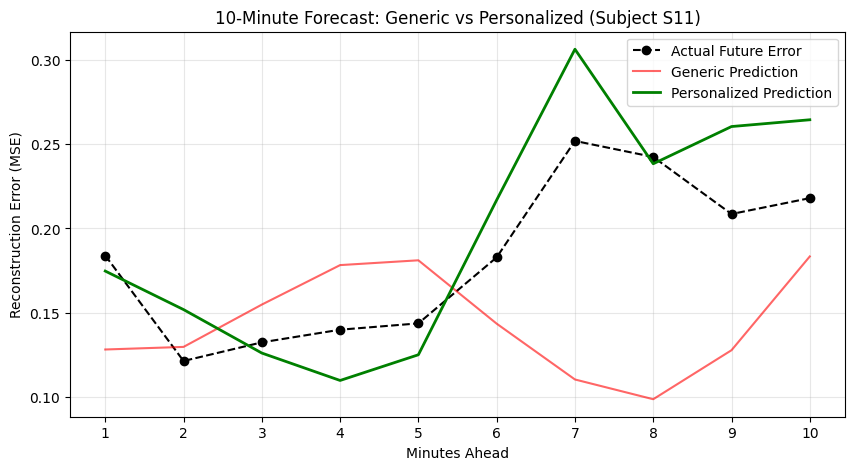


✅ Comparison complete. Check the plot to see the personalization in action!


In [4]:
# ============================================================
# CELL 4 — The Great Generic vs. Personalized Showdown
# ============================================================
# We compare the original "Stranger" model against our new
# "Personalized" expert on the same test samples.
# ============================================================

import matplotlib.pyplot as plt

# --- 1. Load a Fresh Generic Model for Comparison
generic_only = Seq2SeqForecaster().to(device)
generic_only.load_state_dict(torch.load(loso_model_path, map_location=device))
generic_only.eval()

# --- 2. Get Predictions for Both
# generic_forecaster currently holds the personalized weights from Cell 3
personalized_forecaster = generic_forecaster
personalized_forecaster.eval()

with torch.no_grad():
    preds_gen  = generic_only.predict(X_test_p).cpu().numpy()
    preds_pers = personalized_forecaster.predict(X_test_p).cpu().numpy()
    ground_truth = y_test_p.cpu().numpy()

# --- 3. Calculate MAE for both on this specific test slice
mae_gen  = np.mean(np.abs(preds_gen - ground_truth))
mae_pers = np.mean(np.abs(preds_pers - ground_truth))

print('='*60)
print(f'PERFORMANCE COMPARISON FOR SUBJECT {TARGET_SUBJECT}')
print('='*60)
print(f'  Generic (Stranger) MAE    : {mae_gen:.5f}')
print(f'  Personalized (Expert) MAE : {mae_pers:.5f}')
print(f'  Improvement               : {((mae_gen - mae_pers) / mae_gen)*100:.2f}%')
print('='*60)

# --- 4. Visualize the Trajectories
# We will plot the first available test sample (10-minute forecast)
sample_idx = 0
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), ground_truth[sample_idx], 'k--', label='Actual Future Error', marker='o')
plt.plot(range(1, 11), preds_gen[sample_idx], 'r', label='Generic Prediction', alpha=0.6)
plt.plot(range(1, 11), preds_pers[sample_idx], 'g', label='Personalized Prediction', linewidth=2)

plt.title(f'10-Minute Forecast: Generic vs Personalized (Subject {TARGET_SUBJECT})')
plt.xlabel('Minutes Ahead')
plt.ylabel('Reconstruction Error (MSE)')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('personalized_vs_generic_forecast.png')
plt.show()

print(f'\n✅ Comparison complete. Check the plot to see the personalization in action!')

📊 AffectiveROAD Drv1 loaded: 51 minutes of driving.

Nudging model for Drv1...
  Epoch 10/40 | Loss: 0.006952
  Epoch 20/40 | Loss: 0.004123
  Epoch 30/40 | Loss: 0.002566
  Epoch 40/40 | Loss: 0.001843

DOMAIN ADAPTATION RESULTS: Drv1
  Stranger MAE : 0.15344
  Expert MAE   : 0.08490
  Improvement  : 44.67%


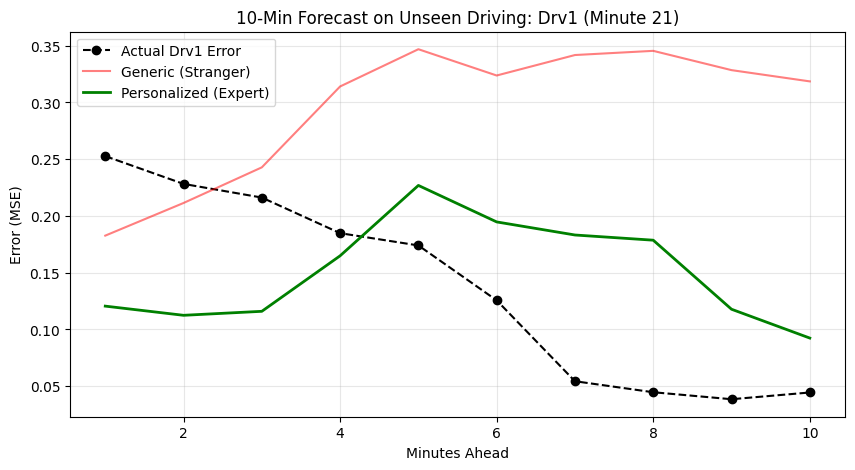

In [5]:
# ============================================================
# CELL 5 — External Domain Personalization (AffectiveROAD Drv1)
# ============================================================
# We take the generic model and see if we can "teach" it the
# quirks of a specific driver (Drv1) in a completely new
# environment (AffectiveROAD).
# ============================================================

import torch.optim as optim
import matplotlib.pyplot as plt

# --- 1. Load Drv1 Data --------------------------------------
TARGET_DRIVE = 'Drv1'
drv_path = os.path.join(PREV_CHECKPOINT_DIR, f'AROAD_{TARGET_DRIVE}_processed.npz')

if not os.path.exists(drv_path):
    print(f"❌ Drive {TARGET_DRIVE} data not found!")
else:
    drv_data = np.load(drv_path, allow_pickle=True)
    drv_seqs = drv_data['base_seqs'] # (N, 5, 10)
    print(f'📊 AffectiveROAD {TARGET_DRIVE} loaded: {len(drv_seqs)} minutes of driving.')

    # --- 2. Generate Timeline (Embeddings + Errors) ---------
    drv_embs, drv_errs = [], []
    masked_ae.eval()
    with torch.no_grad():
        x_all = torch.tensor(drv_seqs, dtype=torch.float32).to(device)
        for i in range(len(x_all)):
            xi = x_all[i].unsqueeze(0)
            drv_embs.append(masked_ae.encode(xi).squeeze(0).cpu().numpy())
            drv_errs.append(torch.mean((xi - masked_ae(xi))**2).item())

    drv_embs, drv_errs = np.array(drv_embs), np.array(drv_errs)
    X_drv, y_drv = build_forecast_samples(drv_embs, drv_errs)

    # Split: First 20 minutes for calibration, the rest for testing
    split_pt = 20
    X_calib = torch.tensor(X_drv[:split_pt], dtype=torch.float32).to(device)
    y_calib = torch.tensor(y_drv[:split_pt], dtype=torch.float32).to(device)
    X_test_unseen = torch.tensor(X_drv[split_pt:], dtype=torch.float32).to(device)
    y_test_unseen = torch.tensor(y_drv[split_pt:], dtype=torch.float32).to(device)

    # --- 3. Baseline Assessment (The Stranger) --------------
    stranger_model = Seq2SeqForecaster().to(device)
    stranger_model.load_state_dict(torch.load(loso_model_path, map_location=device))
    stranger_model.eval()

    with torch.no_grad():
        preds_stranger = stranger_model.predict(X_test_unseen).cpu().numpy()
        mae_stranger   = np.mean(np.abs(preds_stranger - y_test_unseen.cpu().numpy()))

    # --- 4. The Nudge (Fine-Tuning on Drv1 Calibration) -----
    print(f'\nNudging model for {TARGET_DRIVE}...')
    optimizer = optim.Adam(stranger_model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    stranger_model.train()
    for epoch in range(1, 41): # 40 epochs for a slightly stronger nudge
        optimizer.zero_grad()
        preds = stranger_model(X_calib, teacher_forcing_ratio=0.0)
        loss = criterion(preds, y_calib)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f'  Epoch {epoch:2d}/40 | Loss: {loss.item():.6f}')

    # --- 5. Final Comparison (The Unseen Driving Showdown) --
    stranger_model.eval()
    with torch.no_grad():
        preds_expert = stranger_model.predict(X_test_unseen).cpu().numpy()
        mae_expert   = np.mean(np.abs(preds_expert - y_test_unseen.cpu().numpy()))

    print('\n' + '='*60)
    print(f'DOMAIN ADAPTATION RESULTS: {TARGET_DRIVE}')
    print('='*60)
    print(f'  Stranger MAE : {mae_stranger:.5f}')
    print(f'  Expert MAE   : {mae_expert:.5f}')
    print(f'  Improvement  : {((mae_stranger - mae_expert) / mae_stranger)*100:.2f}%')
    print('='*60)

    # FIX: Use a valid index for the test set (which only has 7 samples)
    s_idx = 0

    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 11), y_test_unseen[s_idx].cpu().numpy(), 'k--', label='Actual Drv1 Error', marker='o')
    plt.plot(range(1, 11), preds_stranger[s_idx], 'r', label='Generic (Stranger)', alpha=0.5)
    plt.plot(range(1, 11), preds_expert[s_idx], 'g', label='Personalized (Expert)', linewidth=2)
    plt.title(f'10-Min Forecast on Unseen Driving: {TARGET_DRIVE} (Minute {split_pt + 1})')
    plt.xlabel('Minutes Ahead')
    plt.ylabel('Error (MSE)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig('aroad_personalization_showdown_fixed.png')
    plt.show()